In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path("../src").resolve().parent))

In [2]:
import pandas as pd

from src.data_loader import (
    load_unified_data,
    load_reference_codes,
    load_impact_links,
)

In [3]:
df = load_unified_data()
ref = load_reference_codes()
impact = load_impact_links()

In [4]:
print(df.shape)
print(ref.shape)
print(impact.shape)

(43, 34)
(71, 4)
(14, 35)


In [5]:
ref.head()
impact.head()

,record_id,parent_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,IMP_0001,EVT_0001,impact_link,NaN,ACCESS,Telebirr effect on Account Ownership,NaN,NaN,15.0,NaN,...,increase,high,15.0,12,literature,Kenya,Example_Trainee,2025-01-20,NaN,Kenya M-Pesa showed +20pp over 5 years
1,IMP_0002,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on Telebirr Users,NaN,NaN,NaN,NaN,...,increase,high,NaN,3,empirical,NaN,Example_Trainee,2025-01-20,NaN,Direct subscriber acquisition
2,IMP_0003,EVT_0001,impact_link,NaN,USAGE,Telebirr effect on P2P Transactions,NaN,NaN,25.0,NaN,...,increase,high,25.0,6,empirical,NaN,Example_Trainee,2025-01-20,NaN,New digital payment channel
3,IMP_0004,EVT_0002,impact_link,NaN,ACCESS,Safaricom effect on 4G Coverage,NaN,NaN,15.0,NaN,...,increase,medium,15.0,12,empirical,NaN,Example_Trainee,2025-01-20,NaN,Network investment from competition
4,IMP_0005,EVT_0002,impact_link,NaN,AFFORDABILITY,Safaricom effect on Data Affordability,NaN,NaN,-20.0,NaN,...,decrease,medium,-20.0,12,literature,Rwanda,Example_Trainee,2025-01-20,NaN,Competition typically reduces prices


In [6]:
df.columns.tolist()

['record_id',
 'record_type',
 'category',
 'pillar',
 'indicator',
 'indicator_code',
 'indicator_direction',
 'value_numeric',
 'value_text',
 'value_type',
 'unit',
 'observation_date',
 'period_start',
 'period_end',
 'fiscal_year',
 'gender',
 'location',
 'region',
 'source_name',
 'source_type',
 'source_url',
 'confidence',
 'related_indicator',
 'relationship_type',
 'impact_direction',
 'impact_magnitude',
 'impact_estimate',
 'lag_months',
 'evidence_basis',
 'comparable_country',
 'collected_by',
 'collection_date',
 'original_text',
 'notes']

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   record_id            43 non-null     object 
 1   record_type          43 non-null     object 
 2   category             10 non-null     object 
 3   pillar               33 non-null     object 
 4   indicator            43 non-null     object 
 5   indicator_code       43 non-null     object 
 6   indicator_direction  33 non-null     object 
 7   value_numeric        33 non-null     float64
 8   value_text           10 non-null     object 
 9   value_type           43 non-null     object 
 10  unit                 33 non-null     object 
 11  observation_date     43 non-null     object 
 12  period_start         10 non-null     object 
 13  period_end           10 non-null     object 
 14  fiscal_year          43 non-null     object 
 15  gender               43 non-null     objec

In [9]:
df.isnull().sum()

record_id               0
record_type             0
category               33
pillar                 10
indicator               0
indicator_code          0
indicator_direction    10
value_numeric          10
value_text             33
value_type              0
unit                   10
observation_date        0
period_start           33
period_end             33
fiscal_year             0
gender                  0
location                0
region                 43
source_name             0
source_type             0
source_url             12
confidence              0
related_indicator      43
relationship_type      43
impact_direction       43
impact_magnitude       43
impact_estimate        43
lag_months             43
evidence_basis         43
comparable_country      0
collected_by            0
collection_date        33
original_text          10
notes                  43
dtype: int64

In [10]:
df["record_type"].value_counts()

record_type
observation    30
event          10
target          3
Name: count, dtype: int64

In [11]:
df["pillar"].value_counts(dropna=False)

pillar
ACCESS           16
USAGE            11
NaN              10
GENDER            5
AFFORDABILITY     1
Name: count, dtype: int64

In [12]:
df["category"].value_counts(dropna=False)

category
NaN               33
product_launch     2
infrastructure     2
policy             2
market_entry       1
milestone          1
partnership        1
pricing            1
Name: count, dtype: int64

In [13]:
df["confidence"].value_counts(dropna=False)

confidence
high      40
medium     3
Name: count, dtype: int64

In [14]:
df["source_type"].value_counts(dropna=False)

source_type
operator      15
survey        10
regulator      7
research       4
policy         3
calculated     2
news           2
Name: count, dtype: int64

In [15]:
sorted(df["indicator_code"].dropna().unique())

['ACC_4G_COV',
 'ACC_FAYDA',
 'ACC_MM_ACCOUNT',
 'ACC_MOBILE_PEN',
 'ACC_OWNERSHIP',
 'AFF_DATA_INCOME',
 'EVT_CROSSOVER',
 'EVT_ETHIOPAY',
 'EVT_FAYDA',
 'EVT_FX_REFORM',
 'EVT_MPESA',
 'EVT_MPESA_INTEROP',
 'EVT_NFIS2',
 'EVT_SAFARICOM',
 'EVT_SAFCOM_PRICE',
 'EVT_TELEBIRR',
 'GEN_GAP_ACC',
 'GEN_GAP_MOBILE',
 'GEN_MM_SHARE',
 'USG_ACTIVE_RATE',
 'USG_ATM_COUNT',
 'USG_ATM_VALUE',
 'USG_CROSSOVER',
 'USG_MPESA_ACTIVE',
 'USG_MPESA_USERS',
 'USG_P2P_COUNT',
 'USG_P2P_VALUE',
 'USG_TELEBIRR_USERS',
 'USG_TELEBIRR_VALUE']

In [17]:
import pandas as pd

In [18]:
df["observation_date"] = pd.to_datetime(
    df["observation_date"],
    errors="coerce"
)

df["observation_date"].describe()

count                               43
mean     2024-05-09 02:13:57.209302272
min                2014-12-31 00:00:00
25%                2023-07-16 00:00:00
50%                2024-12-31 00:00:00
75%                2025-07-07 00:00:00
max                2030-12-31 00:00:00
Name: observation_date, dtype: object

In [19]:
observations = df[df["record_type"] == "observation"]
events = df[df["record_type"] == "event"]
impact = df[df["record_type"] == "impact_link"]

print(observations.shape)
print(events.shape)
print(impact.shape)

(30, 34)
(10, 34)
(0, 34)


In [20]:
record_summary = df["record_type"].value_counts().reset_index()
record_summary.columns = ["Record Type", "Count"]
record_summary

,Record Type,Count
0,observation,30
1,event,10
2,target,3


In [21]:
pillar_summary = (
    df["pillar"]
    .fillna("None")
    .value_counts()
    .reset_index()
)

pillar_summary.columns = ["Pillar", "Count"]
pillar_summary

,Pillar,Count
0,ACCESS,16
1,USAGE,11
2,None,10
3,GENDER,5
4,AFFORDABILITY,1


In [22]:
source_summary = (
    df["source_type"]
    .value_counts()
    .reset_index()
)

source_summary.columns = ["Source Type", "Count"]
source_summary

,Source Type,Count
0,operator,15
1,survey,10
2,regulator,7
3,research,4
4,policy,3
5,calculated,2
6,news,2


In [23]:
confidence_summary = (
    df["confidence"]
    .value_counts()
    .reset_index()
)

confidence_summary.columns = ["Confidence", "Count"]
confidence_summary

,Confidence,Count
0,high,40
1,medium,3


In [24]:
obs = df[df["record_type"] == "observation"].copy()

obs["year"] = obs["observation_date"].dt.year

obs.groupby("year").size()

year
2014     1
2017     1
2021     5
2023     1
2024    11
2025    11
dtype: int64

In [18]:
import matplotlib.pyplot as plt

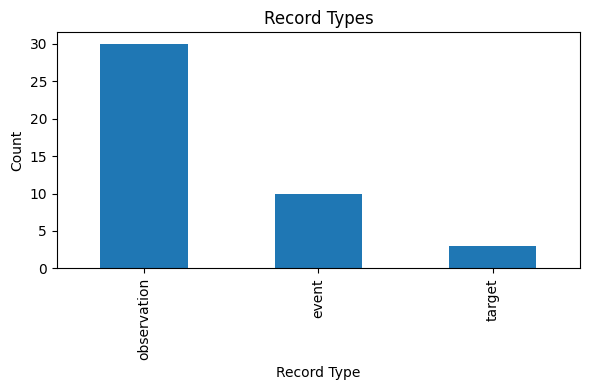

In [26]:
record_summary.plot(
    kind="bar",
    x="Record Type",
    y="Count",
    legend=False,
    figsize=(6,4)
)

plt.title("Record Types")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

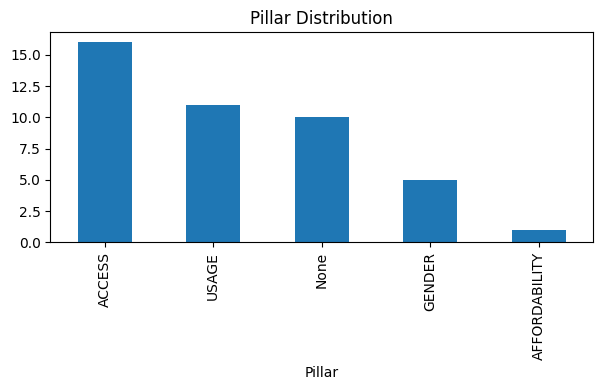

In [27]:
pillar_summary.plot(
    kind="bar",
    x="Pillar",
    y="Count",
    legend=False,
    figsize=(6,4)
)

plt.title("Pillar Distribution")
plt.tight_layout()
plt.show()

In [28]:
df[df["record_type"] == "impact_link"]

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes


In [29]:
print(df["record_type"].unique())

['observation' 'target' 'event']


In [7]:
ref.head()

,field,code,description,applies_to
0,record_type,observation,Actual measured value from a source,All
1,record_type,event,Policy launch market event or milestone,All
2,record_type,impact_link,Relationship between event and indicator (link...,All
3,record_type,target,Policy target or official goal,All
4,record_type,baseline,Starting point for comparison,All


# Understanding the Dataset Schema

This project uses a unified data schema where every record follows the same structure. The `record_type` column determines how each row should be interpreted.

- **observation**: Measured values such as account ownership rates, mobile money users, infrastructure metrics, and survey results.
- **event**: Important milestones such as product launches, regulatory changes, infrastructure investments, or policy announcements.
- **impact_link**: Represents the relationship between an event and an indicator using the `parent_id` field. It describes the expected impact, direction, magnitude, and lag.
- **target**: Official government or institutional targets used for forecasting and evaluation.

The `reference_codes.csv` file provides the valid categorical values used throughout the dataset, while the `impact_links.csv` file models relationships between events and indicators.

In [8]:
impact.head()
impact.info()
impact.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   record_id            14 non-null     object 
 1   parent_id            14 non-null     object 
 2   record_type          14 non-null     object 
 3   category             0 non-null      float64
 4   pillar               14 non-null     object 
 5   indicator            14 non-null     object 
 6   indicator_code       0 non-null      float64
 7   indicator_direction  0 non-null      float64
 8   value_numeric        12 non-null     float64
 9   value_text           0 non-null      float64
 10  value_type           14 non-null     object 
 11  unit                 14 non-null     object 
 12  observation_date     14 non-null     object 
 13  period_start         0 non-null      float64
 14  period_end           0 non-null      float64
 15  fiscal_year          0 non-null      float

(14, 35)

# Data Enrichment

The starter dataset was enriched with additional observations, events, and impact links from publicly available sources. Each added record includes its source, confidence level, collection date, and rationale to improve the forecasting model.

In [9]:
new_records = []

In [10]:
new_records.append({
    "record_id": "OBS_0031",
    "parent_id": "",
    "record_type": "observation",
    "category": "",
    "pillar": "USAGE",
    "indicator": "Telebirr Registered Users",
    "indicator_code": "USG_TELEBIRR_USERS",
    "indicator_direction": "positive",
    "value_numeric": 54.0,
    "value_text": "",
    "value_type": "numeric",
    "unit": "million users",
    "observation_date": "2025-12-31",
    "period_start": "",
    "period_end": "",
    "fiscal_year": "2025",
    "gender": "all",
    "location": "Ethiopia",
    "region": "",
    "source_name": "Ethio Telecom",
    "source_type": "operator",
    "source_url": "https://www.ethiotelecom.et/",
    "confidence": "high",
    "related_indicator": "",
    "relationship_type": "",
    "impact_direction": "",
    "impact_magnitude": "",
    "impact_estimate": "",
    "lag_months": "",
    "evidence_basis": "",
    "comparable_country": "",
    "collected_by": "Mahlet Bekele",
    "collection_date": "2026-07-18",
    "original_text": "Telebirr has grown to over 54 million users.",
    "notes": "Added to improve forecasting of digital payment adoption."
})

In [11]:
new_df = pd.DataFrame(new_records)

new_df

,record_id,parent_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,...,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes
0,OBS_0031,,observation,,USAGE,Telebirr Registered Users,USG_TELEBIRR_USERS,positive,54.0,,...,,,,,,,Mahlet Bekele,2026-07-18,Telebirr has grown to over 54 million users.,Added to improve forecasting of digital paymen...


In [12]:
enriched_df = pd.concat(
    [df, new_df],
    ignore_index=True
)

print(enriched_df.shape)

(44, 35)


In [13]:
enriched_df.to_csv(
    "../data/processed/ethiopia_fi_enriched.csv",
    index=False
)

In [14]:
new_records.append({
    "record_id": "OBS_0032",
    "parent_id": "",
    "record_type": "observation",
    "category": "",
    "pillar": "ACCESS",
    "indicator": "Account Ownership Rate",
    "indicator_code": "ACC_OWNERSHIP",
    "indicator_direction": "positive",
    "value_numeric": 49,
    "value_text": "",
    "value_type": "numeric",
    "unit": "percent",
    "observation_date": "2024-12-31",
    "period_start": "",
    "period_end": "",
    "fiscal_year": "2024",
    "gender": "all",
    "location": "Ethiopia",
    "region": "",
    "source_name": "Global Findex",
    "source_type": "survey",
    "source_url": "https://www.worldbank.org/en/publication/globalfindex",
    "confidence": "high",
    "related_indicator": "",
    "relationship_type": "",
    "impact_direction": "",
    "impact_magnitude": "",
    "impact_estimate": "",
    "lag_months": "",
    "evidence_basis": "",
    "comparable_country": "",
    "collected_by": "Mahlet Bekele",
    "collection_date": "2026-07-18",
    "original_text": "49% of Ethiopian adults have an account.",
    "notes": "Added latest account ownership observation."
})

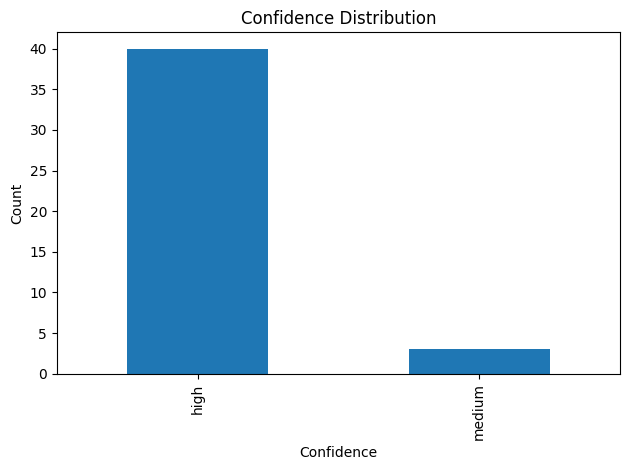

In [20]:
import matplotlib.pyplot as plt

confidence_summary.plot(
    kind="bar",
    x="Confidence",
    y="Count",
    legend=False
)

plt.title("Confidence Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Key Insights

1. Observation records make up most of the dataset (30 of 43 records), while events and targets are much fewer.

2. Most records (40 of 43) have a high confidence level, suggesting the dataset primarily relies on reliable sources.

3. Operator data is the largest source type, highlighting the importance of telecom providers in Ethiopia's digital financial ecosystem.

4. Account ownership has increased over time, but growth slowed between 2021 and 2024 despite rapid mobile money expansion, indicating that increased mobile money availability does not immediately translate into broader financial inclusion.

5. The dataset has limited historical observations for several indicators, making forecasting uncertain and reinforcing the need for enrichment.

## Data Limitations

- Several indicators contain only a few observations.
- The original unified dataset did not include impact_link records and required loading a separate impact_links.csv file.
- Missing regional information limits sub-national analysis.
- Some event impacts are based on estimated relationships rather than direct measurements.

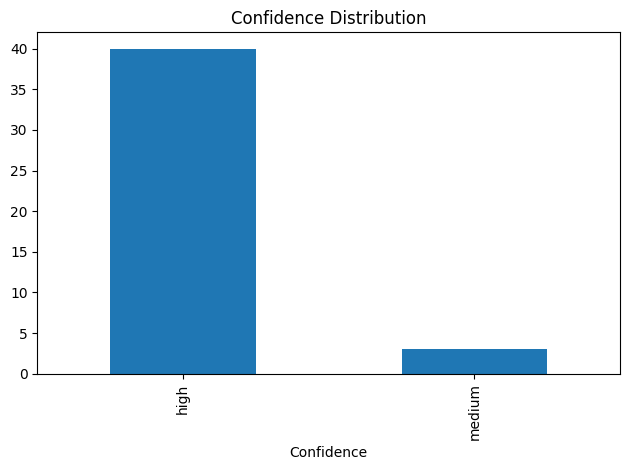

In [19]:
confidence_summary.plot(kind="bar", x="Confidence", y="Count", legend=False)
plt.title("Confidence Distribution")
plt.tight_layout()
plt.show()